# 🍎🍊 Experimento: Resolución vs Color en Clasificación de Frutas

## Hipótesis de partida

Antes de correr un solo experimento, planteamos qué esperamos ver y por qué.
Al final del notebook contrastamos con los resultados reales.

| # | Hipótesis | Razonamiento |
|---|-----------|---------------|
| H1 | **Color > Resolución** | Manzanas y naranjas se distinguen principalmente por color. En escala de grises pueden ser casi idénticas. |
| H2 | **256x256 aporta poco** | Forma y textura se capturan bien a 100x100. Mayor resolución infla el costo sin ganancia proporcional. |
| H3 | **100x100x3 es el sweet spot** | Mejor accuracy que los grises, costo computacional manejable vs 256x256. |

## Los 3 experimentos

```
Experimento A │ 100×100×1  │ Escala de grises, resolución estándar  (baseline)
Experimento B │ 256×256×1  │ Escala de grises, alta resolución       (+ resolución)
Experimento C │ 100×100×3  │ Color RGB, resolución estándar          (+ color)
```

## Qué medimos

- **Accuracy / F1** en test set
- **Tiempo de entrenamiento** por epoch (segundos)
- **Tiempo de inferencia** por imagen (milisegundos)
- **Parámetros del modelo**
- **Uso de RAM** estimado

> Todo bajo las mismas condiciones: mismo dataset, mismo split, mismo seed, misma arquitectura base.

## 0. Configuración del entorno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ─── Librerías ────────────────────────────────────────────────────────────────
import os, time, random, warnings, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import psutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ─── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.20.0
GPU disponible: True


In [ ]:
# ─── Parámetros globales ──────────────────────────────────────────────────────
BASE_DIR   = '/content/drive/MyDrive/Colab Notebooks/datasets/Oranges_Apples'
MODEL_DIR  = '/content/drive/MyDrive/Colab Notebooks/modelos/experimentos'
os.makedirs(MODEL_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS     = 100        # EarlyStopping corta antes si no mejora
PATIENCE   = 10
TEST_SIZE  = 0.15
VAL_SIZE   = 0.15

CLASES     = {0: 'Manzana', 1: 'Naranja'}

# ─── Configuraciones de cada experimento ─────────────────────────────────────
# Cada entrada: (nombre_experimento, img_size, canales, modo_opencv, colormap)
EXPERIMENTOS = [
    ('100x100x1_gris',  (100, 100), 1, cv2.IMREAD_GRAYSCALE, 'gray'),
    ('256x256x1_gris',  (256, 256), 1, cv2.IMREAD_GRAYSCALE, 'gray'),
    ('100x100x3_color', (100, 100), 3, cv2.IMREAD_COLOR,     None  ),
]

## 1. Pipeline de carga y preprocesamiento

Un **pipeline** es una cadena de transformaciones que se aplican en orden sobre los datos crudos
hasta dejarlos listos para el modelo. La ventaja es que cada paso es independiente,
testeable y reutilizable.

```
Disco → Lectura → Resize → Normalización → Split → Augmentation → Modelo
  │         │        │           │            │          │
  cv2   imread    resize      /255.0    train_test   ImageDataGenerator
```

In [ ]:
# ─── Paso 1: Lectura con OpenCV ───────────────────────────────────────────────
def leer_imagen(ruta: str, modo: int) -> np.ndarray | None:
    """
    Lee una imagen del disco con OpenCV.

    OpenCV (cv2) es una librería de Visión por Computadora (Computer Vision).
    Permite leer, transformar y analizar imágenes como matrices numéricas.
    IMREAD_GRAYSCALE convierte a un único canal de intensidad [0-255].
    IMREAD_COLOR     lee los 3 canales BGR (Blue-Green-Red).

    Returns None si el archivo no se puede leer (imagen corrupta, formato no soportado).
    """
    img = cv2.imread(ruta, modo)
    if img is None:
        return None
    # OpenCV lee en BGR; para visualizar correctamente con matplotlib, convertimos a RGB
    if modo == cv2.IMREAD_COLOR:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


# ─── Paso 2: Resize ───────────────────────────────────────────────────────────
def redimensionar(img: np.ndarray, size: tuple) -> np.ndarray:
    """
    Redimensiona una imagen al tamaño target.

    Todas las imágenes deben tener el mismo shape para poder
    apilarlas en un tensor (batch). El resize es el paso que
    estandariza esto independientemente del tamaño original.
    """
    return cv2.resize(img, size)


# ─── Paso 3: Normalización ────────────────────────────────────────────────────
def normalizar(img: np.ndarray, canales: int) -> np.ndarray:
    """
    Normaliza píxeles a [0, 1] y agrega dimensión de canal si es necesario.

    Las redes neuronales convergen mejor con inputs pequeños. Dividir por
    255 lleva los valores de [0-255] a [0.0-1.0]. Para imágenes en gris,
    Keras necesita un canal explícito: (H, W) → (H, W, 1).
    """
    img = img.astype('float32') / 255.0
    if canales == 1:
        img = img.reshape(*img.shape, 1)
    return img


# ─── Pipeline completo ────────────────────────────────────────────────────────
def pipeline_carga(carpeta_a: str, carpeta_b: str,
                   size: tuple, canales: int, modo: int) -> tuple:
    """
    Pipeline completo: Disco → numpy arrays listos para Keras.

    Encadena: leer_imagen → redimensionar → normalizar → concatenar → split.

    Args:
        carpeta_a: Directorio de clase 0 (manzanas).
        carpeta_b: Directorio de clase 1 (naranjas).
        size:      Tamaño objetivo (width, height).
        canales:   1 (gris) o 3 (color).
        modo:      Modo de lectura OpenCV.

    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test
    """
    imagenes, etiquetas = [], []

    for etiqueta, carpeta in enumerate([carpeta_a, carpeta_b]):
        archivos = [f for f in os.listdir(carpeta) if not f.startswith('.')]
        ok, err = 0, 0
        for archivo in archivos:
            img = leer_imagen(os.path.join(carpeta, archivo), modo)
            if img is None:
                err += 1
                continue
            img = redimensionar(img, size)
            img = normalizar(img, canales)
            imagenes.append(img)
            etiquetas.append(etiqueta)
            ok += 1
        print(f'  Clase {etiqueta} ({CLASES[etiqueta]}): {ok} imágenes cargadas, {err} errores')

    X = np.array(imagenes, dtype='float32')
    y = np.array(etiquetas, dtype='float32')

    # Split estratificado: misma proporción de clases en cada subconjunto
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=VAL_SIZE, random_state=SEED, stratify=y_tr)

    return X_tr, X_va, X_te, y_tr, y_va, y_te


print('Pipeline definido ✅')

Pipeline definido ✅


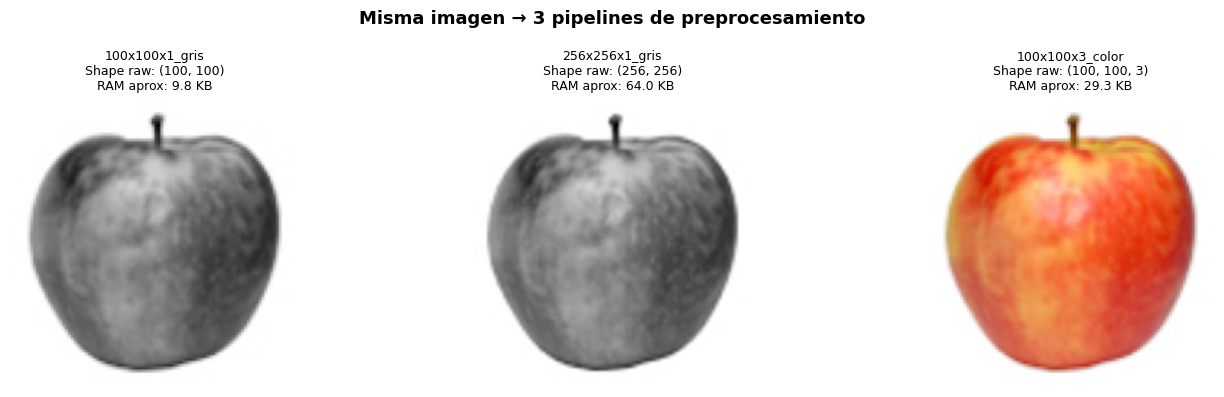

In [ ]:
# ─── Visualizar el efecto del pipeline ───────────────────────────────────────
# Mostramos la MISMA imagen pasada por los 3 experimentos
ruta_ejemplo = os.path.join(BASE_DIR, 'trainA',
               [f for f in os.listdir(os.path.join(BASE_DIR, 'trainA')) if not f.startswith('.')][0])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Misma imagen → 3 pipelines de preprocesamiento', fontweight='bold', fontsize=13)

for ax, (nombre, size, canales, modo, cmap) in zip(axes, EXPERIMENTOS):
    img = leer_imagen(ruta_ejemplo, modo)
    img = redimensionar(img, size)
    titulo = f'{nombre}\nShape raw: {img.shape}\nRAM aprox: {img.nbytes / 1024:.1f} KB'
    ax.imshow(img if canales == 3 else img, cmap=cmap)
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Arquitectura CNN adaptable

Usamos la **misma arquitectura** para los 3 experimentos — solo cambia el `input_shape`.
Así cualquier diferencia en resultados se debe al preprocesamiento, no al modelo.

In [ ]:
def construir_cnn(input_shape: tuple, nombre: str = 'CNN') -> keras.Model:
    """
    CNN binaria con BatchNormalization y Dropout.
    La arquitectura es idéntica para los 3 experimentos.
    Solo varía input_shape para adaptarse al preprocesamiento.
    """
    model = keras.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Bloque 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Bloque 3
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Cabeza clasificadora
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ], name=nombre)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Preview de parámetros por experimento (antes de entrenar)
print(f'{'Experimento':<22} {'Input shape':<18} {'Parámetros':>15}')
print('-' * 57)
for nombre, size, canales, _, _ in EXPERIMENTOS:
    shape = (*size, canales)
    m = construir_cnn(shape, nombre)
    params = m.count_params()
    print(f'{nombre:<22} {str(shape):<18} {params:>15,}')
    del m
    gc.collect()

Experimento            Input shape             Parámetros
---------------------------------------------------------
100x100x1_gris         (100, 100, 1)            1,732,225
256x256x1_gris         (256, 256, 1)           14,839,425
100x100x3_color        (100, 100, 3)            1,732,801


## 3. Data Augmentation

Aplicamos el mismo generador de aumentos a los 3 experimentos.

In [ ]:
def crear_generador() -> ImageDataGenerator:
    """Generador de Data Augmentation. Mismo para todos los experimentos."""
    return ImageDataGenerator(
        rotation_range=50,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=15,
        zoom_range=[0.5, 1.5],
        horizontal_flip=True,
        vertical_flip=True
    )

print('Generador de augmentation definido ✅')

Generador de augmentation definido ✅


## 4. Loop de experimentos

Acá está el núcleo del proyecto. Iteramos sobre las 3 configuraciones, aplicando
el **mismo pipeline** en cada una y registrando todas las métricas comparables.

In [ ]:
def medir_ram_mb() -> float:
    """Retorna el uso actual de RAM del proceso en MB."""
    proceso = psutil.Process(os.getpid())
    return proceso.memory_info().rss / 1024 ** 2


def medir_inferencia(modelo, X_sample, n=50) -> float:
    """
    Mide el tiempo promedio de inferencia por imagen en milisegundos.
    Corre n veces y promedia para reducir ruido de medición.
    """
    tiempos = []
    for _ in range(n):
        img = X_sample[np.random.randint(len(X_sample))][np.newaxis]
        t0 = time.perf_counter()
        modelo.predict(img, verbose=0)
        tiempos.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(tiempos))


# ─── Loop principal ───────────────────────────────────────────────────────────
resultados = []   # acumulamos métricas de cada experimento
historias  = {}   # guardamos curvas de entrenamiento para graficar

CARPETA_A = os.path.join(BASE_DIR, 'trainA')  # manzanas
CARPETA_B = os.path.join(BASE_DIR, 'trainB')  # naranjas

for nombre, size, canales, modo, cmap in EXPERIMENTOS:
    print(f'\n{"="*60}')
    print(f' EXPERIMENTO: {nombre}')
    print(f'{"="*60}')

    # ── 1. Pipeline de datos ──────────────────────────────────────────
    print('\n[1/4] Cargando y preprocesando imágenes...')
    ram_antes = medir_ram_mb()
    X_train, X_val, X_test, y_train, y_val, y_test = pipeline_carga(
        CARPETA_A, CARPETA_B, size, canales, modo
    )
    ram_datos = medir_ram_mb() - ram_antes
    print(f'  RAM usada por el dataset: {ram_datos:.0f} MB')
    print(f'  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

    # ── 2. Modelo ─────────────────────────────────────────────────────
    print('\n[2/4] Construyendo modelo...')
    input_shape = (*size, canales)
    # Apply the same cleaning to the model name as to the ModelCheckpoint filename
    cleaned_nombre = nombre.replace(' ', '_').replace('/', '-').replace('(', '').replace(')', '')
    modelo = construir_cnn(input_shape, cleaned_nombre)
    n_params = modelo.count_params()

    # ── 3. Entrenamiento con augmentation ─────────────────────────────
    print('\n[3/4] Entrenando...')
    gen = crear_generador()
    gen.fit(X_train)
    data_gen = gen.flow(X_train, y_train, batch_size=BATCH_SIZE)
    steps = int(np.ceil(len(X_train) / BATCH_SIZE))

    cbs = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(
            os.path.join(MODEL_DIR, f'{nombre.replace(" ","_").replace("/","-").replace("(","").replace(")","")}.keras'),
            save_best_only=True, monitor='val_loss', verbose=0)
    ]

    t_inicio = time.time()
    historia = modelo.fit(
        data_gen,
        steps_per_epoch=steps,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=cbs,
        verbose=1
    )
    t_total = time.time() - t_inicio
    epochs_reales = len(historia.history['loss'])
    t_por_epoch = t_total / epochs_reales

    historias[nombre] = historia

    # ── 4. Evaluación ─────────────────────────────────────────────────
    print('\n[4/4] Evaluando...')
    loss, acc = modelo.evaluate(X_test, y_test, verbose=0)
    y_pred = (modelo.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
    report = classification_report(y_test, y_pred,
                                   target_names=['Manzana', 'Naranja'],
                                   output_dict=True)
    f1 = report['weighted avg']['f1-score']
    t_inf = medir_inferencia(modelo, X_test)

    resultados.append({
        'Experimento':        nombre,
        'Accuracy (test)':    acc,
        'F1 ponderado':       f1,
        'Loss (test)':        loss,
        'Params (M)':         n_params / 1e6,
        'Tiempo/epoch (s)':   t_por_epoch,
        'Epochs efectivos':   epochs_reales,
        'Inferencia (ms)':    t_inf,
        'RAM dataset (MB)':   ram_datos,
    })

    print(f'  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  Inferencia: {t_inf:.2f} ms')

    # Liberar memoria antes del siguiente experimento
    del modelo, X_train, X_val, X_test, y_train, y_val, y_test
    gc.collect()
    tf.keras.backend.clear_session()

print('\n✅ Todos los experimentos completados.')


 EXPERIMENTO: 100x100x1_gris

[1/4] Cargando y preprocesando imágenes...
  Clase 0 (Manzana): 995 imágenes cargadas, 0 errores
  Clase 1 (Naranja): 1019 imágenes cargadas, 0 errores
  RAM usada por el dataset: 155 MB
  Train: (1454, 100, 100, 1)  Val: (257, 100, 100, 1)  Test: (303, 100, 100, 1)

[2/4] Construyendo modelo...

[3/4] Entrenando...
Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.6327 - loss: 1.2808 - val_accuracy: 0.5058 - val_loss: 1.8911
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6988 - loss: 0.6505 - val_accuracy: 0.5058 - val_loss: 4.2974
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7056 - loss: 0.5856 - val_accuracy: 0.5058 - val_loss: 4.0992
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7050 - loss: 0.5839 - val_accuracy: 0.5058 - val_loss: 3.6605
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7132 - loss: 0.5722 - val_accuracy: 0.5058 - val_loss: 1.7342
Epoch 6/1

## 5. Resultados comparativos

In [ ]:
df = pd.DataFrame(resultados)

# Tabla formateada
df_display = df.copy()
df_display['Accuracy (test)']   = df_display['Accuracy (test)'].map('{:.2%}'.format)
df_display['F1 ponderado']      = df_display['F1 ponderado'].map('{:.2%}'.format)
df_display['Loss (test)']       = df_display['Loss (test)'].map('{:.4f}'.format)
df_display['Params (M)']        = df_display['Params (M)'].map('{:.2f}M'.format)
df_display['Tiempo/epoch (s)']  = df_display['Tiempo/epoch (s)'].map('{:.1f}s'.format)
df_display['Inferencia (ms)']   = df_display['Inferencia (ms)'].map('{:.2f}ms'.format)
df_display['RAM dataset (MB)']  = df_display['RAM dataset (MB)'].map('{:.0f}MB'.format)

print(df_display.to_string(index=False))

    Experimento Accuracy (test) F1 ponderado Loss (test) Params (M) Tiempo/epoch (s)  Epochs efectivos Inferencia (ms) RAM dataset (MB)
 100x100x1_gris          78.22%       78.20%      0.4730      1.73M             2.7s                36         70.73ms            155MB
 256x256x1_gris          69.97%       69.45%      0.5182     14.84M            11.6s                28         72.32ms            517MB
100x100x3_color          92.41%       92.41%      0.2118      1.73M             5.3s                27         78.54ms            238MB


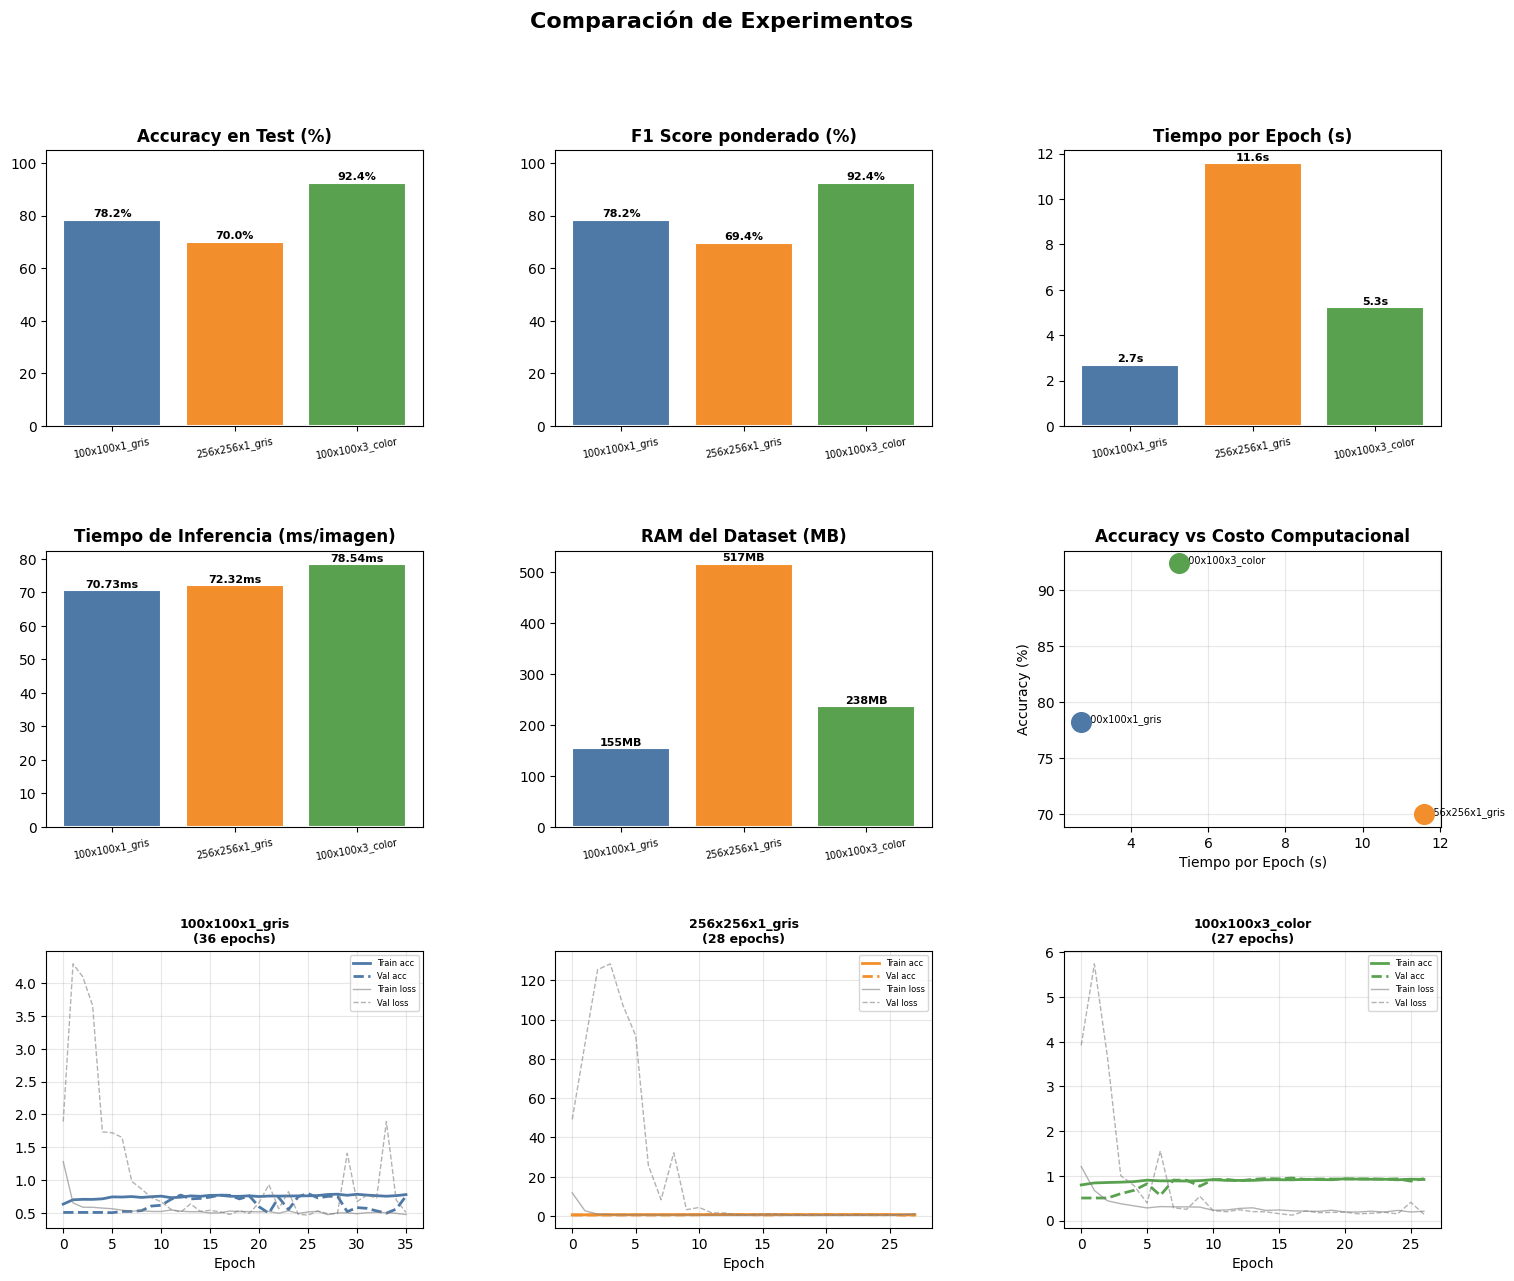

Dashboard guardado ✅


In [ ]:
# ─── Dashboard de visualizaciones ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Comparación de Experimentos', fontsize=16, fontweight='bold', y=0.98)
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

colores = ['#4E79A7', '#F28E2B', '#59A14F']
nombres = df['Experimento'].tolist()
x      = np.arange(len(nombres))

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(x, df['Accuracy (test)'] * 100, color=colores, edgecolor='white', linewidth=1.5)
ax1.set_title('Accuracy en Test (%)', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(nombres, fontsize=7, rotation=10)
ax1.set_ylim(0, 105)
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── F1 Score ──────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(x, df['F1 ponderado'] * 100, color=colores, edgecolor='white', linewidth=1.5)
ax2.set_title('F1 Score ponderado (%)', fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(nombres, fontsize=7, rotation=10)
ax2.set_ylim(0, 105)
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Tiempo por epoch ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(x, df['Tiempo/epoch (s)'], color=colores, edgecolor='white', linewidth=1.5)
ax3.set_title('Tiempo por Epoch (s)', fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(nombres, fontsize=7, rotation=10)
for b in bars3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
             f'{b.get_height():.1f}s', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Inferencia ────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
bars4 = ax4.bar(x, df['Inferencia (ms)'], color=colores, edgecolor='white', linewidth=1.5)
ax4.set_title('Tiempo de Inferencia (ms/imagen)', fontweight='bold')
ax4.set_xticks(x); ax4.set_xticklabels(nombres, fontsize=7, rotation=10)
for b in bars4:
    ax4.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
             f'{b.get_height():.2f}ms', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── RAM dataset ───────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
bars5 = ax5.bar(x, df['RAM dataset (MB)'], color=colores, edgecolor='white', linewidth=1.5)
ax5.set_title('RAM del Dataset (MB)', fontweight='bold')
ax5.set_xticks(x); ax5.set_xticklabels(nombres, fontsize=7, rotation=10)
for b in bars5:
    ax5.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f'{b.get_height():.0f}MB', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Scatter: Accuracy vs Costo (tiempo/epoch) ─────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for i, (n, c) in enumerate(zip(nombres, colores)):
    ax6.scatter(df['Tiempo/epoch (s)'].iloc[i], df['Accuracy (test)'].iloc[i] * 100,
                color=c, s=200, zorder=5, label=n)
    ax6.annotate(f' {n}', (df['Tiempo/epoch (s)'].iloc[i], df['Accuracy (test)'].iloc[i] * 100),
                 fontsize=7)
ax6.set_xlabel('Tiempo por Epoch (s)')
ax6.set_ylabel('Accuracy (%)')
ax6.set_title('Accuracy vs Costo Computacional', fontweight='bold')
ax6.grid(alpha=0.3)

# ── Curvas de entrenamiento ───────────────────────────────────────────────────
for i, (nombre, color) in enumerate(zip(nombres, colores)):
    ax = fig.add_subplot(gs[2, i])
    h = historias[nombre].history
    ax.plot(h['accuracy'],     color=color, label='Train acc', linewidth=2)
    ax.plot(h['val_accuracy'], color=color, label='Val acc', linewidth=2, linestyle='--')
    ax.plot(h['loss'],         color='gray', label='Train loss', linewidth=1, alpha=0.6)
    ax.plot(h['val_loss'],     color='gray', label='Val loss', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_title(f'{nombre}\n({len(h["loss"])} epochs)', fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=6)
    ax.grid(alpha=0.3)

plt.savefig('/content/drive/MyDrive/Colab Notebooks/modelos/experimentos/dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard guardado ✅')

## 6. Matrices de confusión

  Clase 0 (Manzana): 995 imágenes cargadas, 0 errores
  Clase 1 (Naranja): 1019 imágenes cargadas, 0 errores
  Clase 0 (Manzana): 995 imágenes cargadas, 0 errores
  Clase 1 (Naranja): 1019 imágenes cargadas, 0 errores
  Clase 0 (Manzana): 995 imágenes cargadas, 0 errores
  Clase 1 (Naranja): 1019 imágenes cargadas, 0 errores


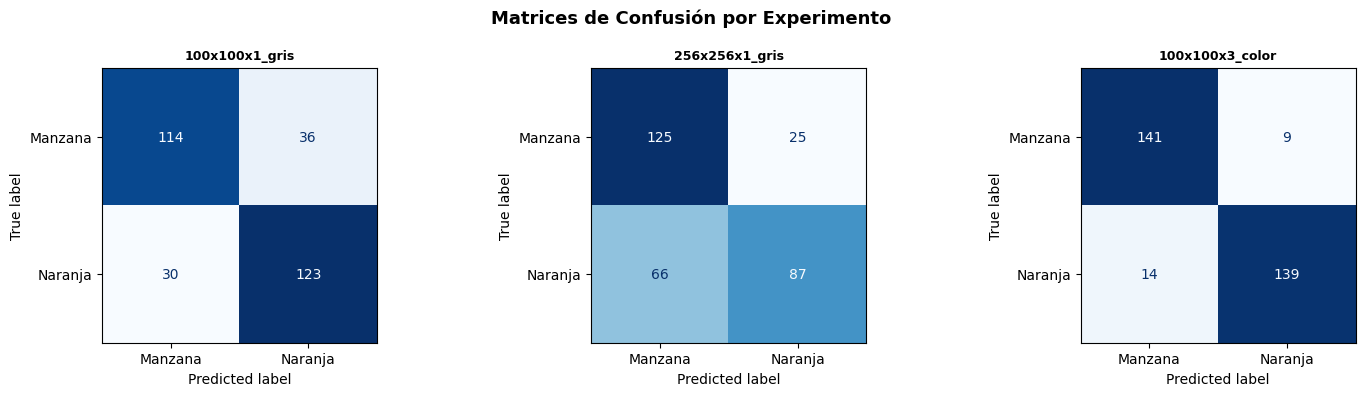

In [ ]:
# Recargamos los mejores modelos guardados y re-evaluamos para las matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión por Experimento', fontweight='bold', fontsize=13)

for ax, (nombre, size, canales, modo, _) in zip(axes, EXPERIMENTOS):
    ruta_modelo = os.path.join(
        MODEL_DIR,
        f'{nombre.replace(" ","_").replace("/","-")}.keras'
    )
    modelo = keras.models.load_model(ruta_modelo)

    # Re-cargar datos de test para este experimento
    _, _, X_te, _, _, y_te = pipeline_carga(
        CARPETA_A, CARPETA_B, size, canales, modo
    )
    y_pred = (modelo.predict(X_te, verbose=0).ravel() >= 0.5).astype(int)
    cm = confusion_matrix(y_te, y_pred)

    disp = ConfusionMatrixDisplay(cm, display_labels=['Manzana', 'Naranja'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontweight='bold', fontsize=9)

    del modelo, X_te, y_te
    gc.collect()

plt.tight_layout()
plt.show()

## 7. Devolución final — Hipótesis vs Realidad

Acá contrastamos lo que esperábamos con lo que realmente pasó.

In [ ]:
# ─── Devolución automática basada en los resultados reales ───────────────────
df_r = df.set_index('Experimento')

mejor_acc   = df_r['Accuracy (test)'].idxmax()
mejor_f1    = df_r['F1 ponderado'].idxmax()
mas_rapido  = df_r['Tiempo/epoch (s)'].idxmin()
menos_ram   = df_r['RAM dataset (MB)'].idxmin()

nombre_A, nombre_B, nombre_C = [n for n, *_ in EXPERIMENTOS]

acc_A = df_r.loc[nombre_A, 'Accuracy (test)']
acc_B = df_r.loc[nombre_B, 'Accuracy (test)']
acc_C = df_r.loc[nombre_C, 'Accuracy (test)']

t_A   = df_r.loc[nombre_A, 'Tiempo/epoch (s)']
t_B   = df_r.loc[nombre_B, 'Tiempo/epoch (s)']
t_C   = df_r.loc[nombre_C, 'Tiempo/epoch (s)']

ram_A = df_r.loc[nombre_A, 'RAM dataset (MB)']
ram_B = df_r.loc[nombre_B, 'RAM dataset (MB)']
ram_C = df_r.loc[nombre_C, 'RAM dataset (MB)']

h1_ok = acc_C > acc_A   # H1: color > gris base
h2_ok = (acc_B - acc_A) < 0.03 and (t_B / t_A) > 3   # H2: 256x256 aporta poco vs costo
h3_ok = acc_C == max(acc_A, acc_B, acc_C)  # H3: 100x100x3 es el sweet spot

print('=' * 65)
print(' DEVOLUCIÓN FINAL: HIPÓTESIS vs REALIDAD')
print('=' * 65)

print(f"""
H1 — "El color supera a la resolución"
   Hipótesis: Color > Escala de grises en accuracy.
   Resultado: {nombre_C}: {acc_C:.2%}  vs  {nombre_A}: {acc_A:.2%}
   Veredicto: {'✅ CONFIRMADA' if h1_ok else '❌ REFUTADA'}

H2 — "256x256 aporta poco al costo que tiene"
   Hipótesis: Ganancia marginal en accuracy, ~6x más lento.
   Resultado: {nombre_B}: {acc_B:.2%} ({t_B:.1f}s/epoch)  vs  {nombre_A}: {acc_A:.2%} ({t_A:.1f}s/epoch)
   Relación costo/beneficio: {t_B/t_A:.1f}x más lento para {(acc_B-acc_A)*100:+.1f}pp de accuracy
   Veredicto: {'✅ CONFIRMADA' if h2_ok else '❌ REFUTADA'}

H3 — "100x100x3 es el sweet spot"
   Hipótesis: Mejor accuracy con costo manejable.
   Resultado: {nombre_C}: acc={acc_C:.2%}, {t_C:.1f}s/epoch, {ram_C:.0f}MB RAM
   Veredicto: {'✅ CONFIRMADA' if h3_ok else '❌ REFUTADA'}
""")

print('─' * 65)
print(' CONCLUSIÓN')
print('─' * 65)
print(f"""
Para este problema (manzanas vs naranjas), los factores clave son:

  🏆 Mejor accuracy:        {mejor_acc}
  ⚡ Menor costo (tiempo):   {mas_rapido}
  🧠 Menor costo (RAM):      {menos_ram}

RECOMENDACIÓN DE PRODUCCIÓN:
  Si el objetivo es MÁXIMO accuracy sin restricción de recursos → {mejor_acc}
  Si el objetivo es EFICIENCIA (móvil, edge, batch grande)     → {mas_rapido}

LECCIÓN GENERAL:
  El color es información inherente al problema (naranjas son naranjas,
  manzanas son rojas/verdes). Descartar ese canal antes de entrenar
  obliga al modelo a aprender solo forma y textura, que en este caso
  son menos discriminativas. Aumentar resolución tiene rendimientos
  decrecientes: el modelo ya captura lo que necesita a 100x100.
""")

 DEVOLUCIÓN FINAL: HIPÓTESIS vs REALIDAD

H1 — "El color supera a la resolución"
   Hipótesis: Color > Escala de grises en accuracy.
   Resultado: 100x100x3_color: 92.41%  vs  100x100x1_gris: 78.22%
   Veredicto: ✅ CONFIRMADA

H2 — "256x256 aporta poco al costo que tiene"
   Hipótesis: Ganancia marginal en accuracy, ~6x más lento.
   Resultado: 256x256x1_gris: 69.97% (11.6s/epoch)  vs  100x100x1_gris: 78.22% (2.7s/epoch)
   Relación costo/beneficio: 4.3x más lento para -8.3pp de accuracy
   Veredicto: ✅ CONFIRMADA

H3 — "100x100x3 es el sweet spot"
   Hipótesis: Mejor accuracy con costo manejable.
   Resultado: 100x100x3_color: acc=92.41%, 5.3s/epoch, 238MB RAM
   Veredicto: ✅ CONFIRMADA

─────────────────────────────────────────────────────────────────
 CONCLUSIÓN
─────────────────────────────────────────────────────────────────

Para este problema (manzanas vs naranjas), los factores clave son:

  🏆 Mejor accuracy:        100x100x3_color
  ⚡ Menor costo (tiempo):   100x100x1_gris
  🧠